In [3]:
# Import the main libraries used throughout the analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the January 2024 NYC Yellow Taxi trip dataset

df = pd.read_parquet("./yellow_tripdata_2024-01.parquet")

# Display the first five rows
df.head()

# Display the number of rows and columns

print("Dataset shape:", df.shape)

# Display information about columns, data types,
# missing values and memory usage

df.info()

# Display statistical summary for numerical columns

df.describe()

# Display all column names

df.columns.tolist()



Dataset shape: (2964624, 19)
<class 'pandas.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airp

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee']

In [6]:
# Count missing values in each column

missing_values = df.isna().sum()

# Calculate the percentage of missing values

missing_percentage = (df.isna().mean() * 100).round(2)

# Combine both results into one table

missing_report = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_report.sort_values(
    by="Missing Values",
    ascending=False
)

# Check for completely duplicated rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# Count trips with zero or negative distance

non_positive_distance = (df["trip_distance"] <= 0).sum()

print(
    "Trips with non-positive distance:",
    non_positive_distance
)

# Count negative fare values

negative_fare = (df["fare_amount"] < 0).sum()

# Count zero fare values

zero_fare = (df["fare_amount"] == 0).sum()

print("Negative fare:", negative_fare)
print("Zero fare:", zero_fare)

# Count transactions with a negative total amount

negative_total = (df["total_amount"] < 0).sum()

print("Negative total amount:", negative_total)

# Check the minimum and maximum pickup dates

print("Minimum pickup date:", df["tpep_pickup_datetime"].min())
print("Maximum pickup date:", df["tpep_pickup_datetime"].max())

# Count trips picked up before January 2024

before_january = (
    df["tpep_pickup_datetime"] < "2024-01-01"
).sum()

# Count trips picked up on or after February 2024

after_january = (
    df["tpep_pickup_datetime"] >= "2024-02-01"
).sum()

print("Trips before January 2024:", before_january)
print("Trips on/after February 2024:", after_january)



Number of duplicate rows: 0
Trips with non-positive distance: 60371
Negative fare: 37448
Zero fare: 893
Negative total amount: 35504
Minimum pickup date: 2002-12-31 22:59:39
Maximum pickup date: 2024-02-01 00:01:15
Trips before January 2024: 15
Trips on/after February 2024: 3


In [14]:
# Columns with missing values identified during the quality assessment

missing_cols = [
    "passenger_count",
    "RatecodeID",
    "store_and_fwd_flag",
    "congestion_surcharge",
    "Airport_fee"
]

# Check how many rows have all five values missing simultaneously

all_missing = df[missing_cols].isna().all(axis=1).sum()

print(
    "Rows where all five columns are missing:",
    all_missing
)

# Display examples of trips with negative fare amounts

negative_fare_rows = df[
    df["fare_amount"] < 0
][[
    "fare_amount",
    "trip_distance",
    "passenger_count",
    "payment_type",
    "total_amount"
]]

negative_fare_rows.head(20)

# Display examples of trips with zero distance

zero_distance_rows = df[
    df["trip_distance"] == 0
][[
    "fare_amount",
    "trip_distance",
    "passenger_count",
    "payment_type",
    "total_amount"
]]

print(zero_distance_rows)

zero_distance_rows.head(20)



Rows where all five columns are missing: 140162
         fare_amount  trip_distance  passenger_count  payment_type  \
17              3.00            0.0              1.0             2   
23              3.00            0.0              1.0             2   
111             4.40            0.0              1.0             1   
198            10.70            0.0              2.0             1   
199            19.80            0.0              1.0             1   
...              ...            ...              ...           ...   
2964528        14.00            0.0              NaN             0   
2964535         9.67            0.0              NaN             0   
2964540        14.25            0.0              NaN             0   
2964550        10.75            0.0              NaN             0   
2964561         9.16            0.0              NaN             0   

         total_amount  
17               8.00  
23               8.00  
111             11.40  
198            

,fare_amount,trip_distance,passenger_count,payment_type,total_amount
17,3.0,0.0,1.0,2,8.00
23,3.0,0.0,1.0,2,8.00
111,4.4,0.0,1.0,1,11.40
198,10.7,0.0,2.0,1,18.80
199,19.8,0.0,1.0,1,26.80
251,52.5,0.0,1.0,1,60.94
580,12.2,0.0,1.0,1,13.20
593,10.0,0.0,1.0,1,13.20
600,6.5,0.0,2.0,2,11.50
709,180.0,0.0,4.0,1,217.20


In [8]:
# PACE: Data Quality Investigation
# This cell describes the anomalies before any cleaning decision is made.

missing_cols = [
    "passenger_count", "RatecodeID", "store_and_fwd_flag",
    "congestion_surcharge", "Airport_fee"
]
investigation_cols = [
    "VendorID", "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "RatecodeID", "store_and_fwd_flag",
    "PULocationID", "DOLocationID", "payment_type", "fare_amount",
    "extra", "mta_tax", "tip_amount", "tolls_amount",
    "improvement_surcharge", "total_amount", "congestion_surcharge",
    "Airport_fee", "trip_type"
]
available_cols = [column for column in investigation_cols if column in df.columns]

investigation = df[available_cols].copy()
investigation["trip_duration_minutes"] = (
    investigation["tpep_dropoff_datetime"]
    - investigation["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# 1. Missingness pattern and possible source/system relationship
missing_flags = investigation[missing_cols].isna()
investigation["missing_five_fields"] = missing_flags.all(axis=1)
investigation["missing_field_count"] = missing_flags.sum(axis=1)

print("MISSINGNESS INVESTIGATION")
print("Rows with all five fields missing:", investigation["missing_five_fields"].sum())
print("Missing-field count distribution:")
print(investigation["missing_field_count"].value_counts().sort_index())

missing_by_vendor = (
    investigation.groupby("VendorID", dropna=False)
    .agg(
        records=("VendorID", "size"),
        rows_with_all_five_missing=("missing_five_fields", "sum"),
        missing_rate=("missing_five_fields", "mean"),
        median_fare=("fare_amount", "median"),
        median_distance=("trip_distance", "median")
    )
    .sort_values("missing_rate", ascending=False)
)
print("\nMissingness by vendor:")
print(missing_by_vendor)

# Compare all-five-missing rows with complete rows on operational fields.
missing_comparison = (
    investigation.groupby("missing_five_fields", dropna=False)
    .agg(
        records=("fare_amount", "size"),
        median_fare=("fare_amount", "median"),
        median_total=("total_amount", "median"),
        median_distance=("trip_distance", "median"),
        median_duration_minutes=("trip_duration_minutes", "median"),
        negative_fare_rows=("fare_amount", lambda values: (values < 0).sum()),
        zero_distance_rows=("trip_distance", lambda values: (values == 0).sum())
    )
)
print("\nAll-five-missing versus other rows:")
print(missing_comparison)

# 2. Financial anomaly profiles
print("\nFINANCIAL ANOMALY INVESTIGATION")
financial_masks = {
    "negative_fare": investigation["fare_amount"] < 0,
    "zero_fare": investigation["fare_amount"] == 0,
    "negative_total": investigation["total_amount"] < 0,
    "zero_total": investigation["total_amount"] == 0
}

anomaly_profile = []
for name, mask in financial_masks.items():
    subset = investigation.loc[mask]
    anomaly_profile.append({
        "anomaly": name,
        "records": len(subset),
        "share_of_data_pct": round(len(subset) / len(investigation) * 100, 3),
        "median_distance": subset["trip_distance"].median(),
        "median_duration_minutes": subset["trip_duration_minutes"].median(),
        "median_fare": subset["fare_amount"].median(),
        "median_total": subset["total_amount"].median()
    })
print(pd.DataFrame(anomaly_profile).set_index("anomaly"))

negative_fare_by_payment = (
    investigation.loc[financial_masks["negative_fare"]]
    .groupby("payment_type", dropna=False)
    .agg(
        records=("fare_amount", "size"),
        median_fare=("fare_amount", "median"),
        median_total=("total_amount", "median"),
        median_distance=("trip_distance", "median"),
        median_duration_minutes=("trip_duration_minutes", "median")
    )
    .sort_values("records", ascending=False)
)
print("\nNegative fares by payment type:")
print(negative_fare_by_payment)

negative_total_examples = investigation.loc[
    financial_masks["negative_total"],
    [column for column in [
        "VendorID", "payment_type", "RatecodeID", "trip_distance",
        "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
        "congestion_surcharge", "Airport_fee", "total_amount"
    ] if column in investigation.columns]
].head(20)
print("\nExamples of negative total amounts:")
print(negative_total_examples)

# 3. Zero-distance trips: distinguish same-location/short-duration trips from anomalies.
print("\nZERO-DISTANCE INVESTIGATION")
investigation["same_pickup_dropoff"] = (
    investigation["PULocationID"] == investigation["DOLocationID"]
)
investigation["short_duration"] = investigation["trip_duration_minutes"].between(0, 5, inclusive="both")

zero_distance_summary = (
    investigation.loc[investigation["trip_distance"] == 0]
    .groupby(["same_pickup_dropoff", "short_duration"], dropna=False)
    .agg(
        records=("trip_distance", "size"),
        median_fare=("fare_amount", "median"),
        median_total=("total_amount", "median"),
        negative_fare_rows=("fare_amount", lambda values: (values < 0).sum()),
        zero_fare_rows=("fare_amount", lambda values: (values == 0).sum())
    )
    .reset_index()
    .sort_values("records", ascending=False)
)
print(zero_distance_summary)

zero_distance_by_ratecode = (
    investigation.loc[investigation["trip_distance"] == 0]
    .groupby("RatecodeID", dropna=False)
    .agg(
        records=("trip_distance", "size"),
        median_fare=("fare_amount", "median"),
        zero_fare_rows=("fare_amount", lambda values: (values == 0).sum()),
        negative_fare_rows=("fare_amount", lambda values: (values < 0).sum())
    )
    .sort_values("records", ascending=False)
)
print("\nZero-distance trips by rate code:")
print(zero_distance_by_ratecode)

# 4. Reconciliation check: compare total_amount with its observable components.
component_cols = [
    "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
    "improvement_surcharge", "congestion_surcharge", "Airport_fee"
]
existing_components = [column for column in component_cols if column in investigation.columns]
investigation["component_sum"] = investigation[existing_components].fillna(0).sum(axis=1)
investigation["total_component_difference"] = (
    investigation["total_amount"] - investigation["component_sum"]
)

reconciliation = investigation["total_component_difference"].describe()
print("\nTOTAL AMOUNT RECONCILIATION")
print(reconciliation)
print("Rows with absolute reconciliation difference > $0.01:", (
    investigation["total_component_difference"].abs() > 0.01
).sum())

# No rows are removed or imputed here. Findings must be reviewed before cleaning.


MISSINGNESS INVESTIGATION
Rows with all five fields missing: 140162
Missing-field count distribution:
missing_field_count
0    2824462
5     140162
Name: count, dtype: int64

Missingness by vendor:
          records  rows_with_all_five_missing  missing_rate  median_fare  \
VendorID                                                                   
6             260                         260      1.000000        46.23   
1          729732                       48455      0.066401        12.80   
2         2234632                       91447      0.040923        12.80   

          median_distance  
VendorID                   
6                   11.22  
1                    1.60  
2                    1.70  

All-five-missing versus other rows:
                     records  median_fare  median_total  median_distance  \
missing_five_fields                                                        
False                2824462        12.80         20.00             1.67   
True            

## PACE: Data Quality Investigation Findings

### Evidence-based observations

- The five investigated fields are missing together: there are no rows with only one to four of these fields missing. This indicates a shared recording or source-system pattern rather than independent missingness.
- The all-five-missing group contains 140,162 rows. Its median fare, total amount, distance, and duration differ from the rest of the data, so the rows should not be removed or imputed without understanding their origin.
- Missingness varies by vendor. Vendor 6 has all of its observed rows in this pattern, while Vendors 1 and 2 have lower but non-zero rates. Vendor-level source documentation should be checked.
- Negative fares are concentrated in payment types 4 and 2. The negative-total examples also show several negative fare components, which is consistent with reversals, refunds, or cancellation records and should be validated against the data dictionary.
- Zero-distance trips are heterogeneous. Many have different pickup and drop-off zones or durations longer than five minutes, so zero distance is not sufficient evidence that a record is invalid.
- The total amount usually reconciles to the visible components, but 761,838 rows differ by more than $0.01. The next investigation should determine whether this is caused by omitted fields, null handling, rounding, or a documented surcharge rule.

### Investigation decisions

No rows have been deleted, imputed, capped, or otherwise cleaned. The next PACE step is to validate these hypotheses using the TLC data dictionary and targeted subgroup checks before defining cleaning rules.


In [9]:
# PACE: Data Preparation and Cleaning Decisions
# Keep the raw df unchanged and create an analysis-ready copy.

df_analysis = df.copy()

# Quality flags preserve anomaly information for later analysis.
df_analysis["is_out_of_january"] = (
    (df_analysis["tpep_pickup_datetime"] < "2024-01-01") |
    (df_analysis["tpep_pickup_datetime"] >= "2024-02-01")
)
df_analysis["has_missing_operational_fields"] = (
    df_analysis[missing_cols].isna().any(axis=1)
)
df_analysis["has_all_missing_operational_fields"] = (
    df_analysis[missing_cols].isna().all(axis=1)
)
df_analysis["is_negative_fare"] = df_analysis["fare_amount"] < 0
df_analysis["is_zero_fare"] = df_analysis["fare_amount"] == 0
df_analysis["is_negative_total"] = df_analysis["total_amount"] < 0
df_analysis["is_zero_distance"] = df_analysis["trip_distance"] == 0
df_analysis["is_non_positive_distance"] = df_analysis["trip_distance"] <= 0

# Only records outside the requested month are excluded from the January analysis set.
df_analysis_january = df_analysis.loc[
    ~df_analysis["is_out_of_january"]
].copy()

quality_summary = pd.DataFrame({
    "raw_rows": [len(df_analysis)],
    "january_analysis_rows": [len(df_analysis_january)],
    "excluded_out_of_period": [df_analysis["is_out_of_january"].sum()],
    "negative_fare_flags": [df_analysis_january["is_negative_fare"].sum()],
    "negative_total_flags": [df_analysis_january["is_negative_total"].sum()],
    "zero_distance_flags": [df_analysis_january["is_zero_distance"].sum()],
    "all_missing_fields_flags": [
        df_analysis_january["has_all_missing_operational_fields"].sum()
    ]
})

print("DATA PREPARATION SUMMARY")
print(quality_summary.T.rename(columns={0: "records"}))
print("\nRaw data preserved:", len(df) == len(df_analysis))
print("Anomalies retained in analysis set:", (
    df_analysis_january["is_negative_fare"].sum() > 0 and
    df_analysis_january["is_zero_distance"].sum() > 0
))


DATA PREPARATION SUMMARY
                          records
raw_rows                  2964624
january_analysis_rows     2964606
excluded_out_of_period         18
negative_fare_flags         37447
negative_total_flags        35503
zero_distance_flags         60371
all_missing_fields_flags   140162

Raw data preserved: True
Anomalies retained in analysis set: True


## PACE: Data Preparation Decisions

- The raw dataset `df` is preserved unchanged for auditability.
- The 18 pickup records outside January 2024 are excluded from `df_analysis_january` because the project scope is January 2024.
- Negative fares, negative totals, zero fares, and zero-distance trips are retained and represented by quality flags. The investigation indicates that these groups may include reversals, cancellations, or legitimate special cases.
- Missing operational fields are not imputed at this stage. Missingness indicators are retained so later analysis can test whether missingness is associated with fare or trip behavior.
- No duplicate removal was required because the duplicate count was zero.


EXECUTIVE METRICS
analysis_rows               2964606.00
core_valid_rows             2869979.00
core_share_pct                   96.81
total_revenue_core         78478894.71
median_fare                      12.80
median_total_amount              20.16
median_distance_miles             1.70
median_duration_minutes          11.72
median_fare_per_mile              7.18
dtype: float64

TOP HOURS BY TRIP VOLUME
              trips     revenue  median_fare  median_distance  \
pickup_hour                                                     
18           206279  5538329.76         12.1             1.60   
17           200305  5639454.17         12.8             1.60   
16           184966  5503923.89         12.8             1.64   
15           184000  5042345.79         12.8             1.60   
19           178807  4947524.76         12.1             1.68   

             median_duration  revenue_share_pct  
pickup_hour                                      
18                 11.666667      

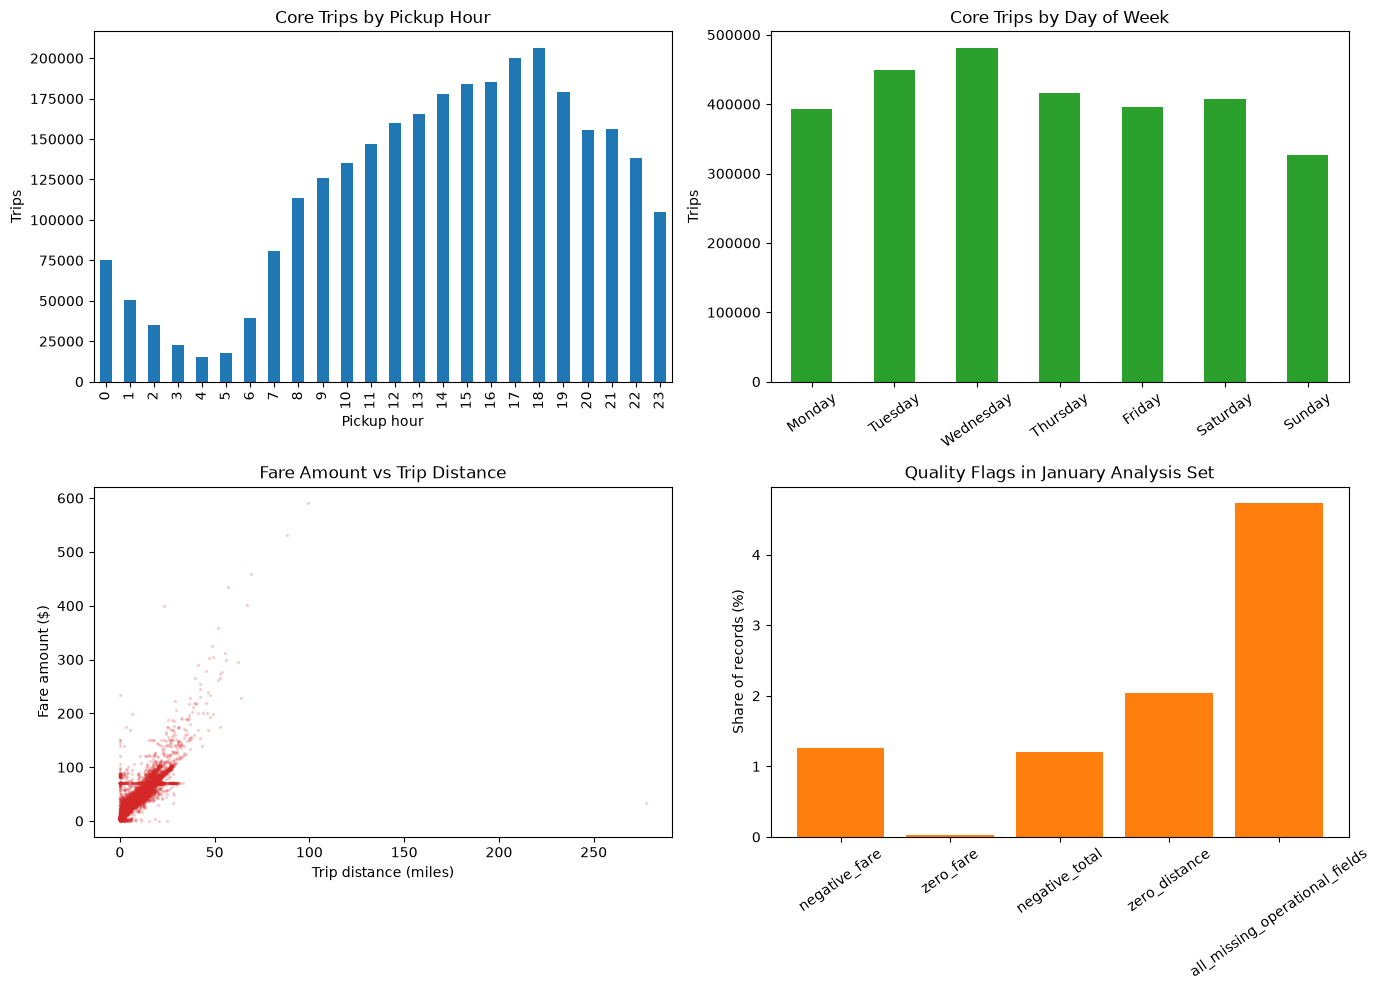

In [10]:
# PACE: Analyze and Construct Business Metrics
# Core metrics exclude impossible financial, distance, and duration values.

analysis = df_analysis_january.copy()
analysis["pickup_hour"] = analysis["tpep_pickup_datetime"].dt.hour
analysis["pickup_day"] = analysis["tpep_pickup_datetime"].dt.day_name()
analysis["pickup_date"] = analysis["tpep_pickup_datetime"].dt.date
analysis["trip_duration_minutes"] = (
    analysis["tpep_dropoff_datetime"]
    - analysis["tpep_pickup_datetime"]
).dt.total_seconds() / 60
analysis["fare_per_mile"] = np.where(
    analysis["trip_distance"] > 0,
    analysis["fare_amount"] / analysis["trip_distance"],
    np.nan
)
analysis["total_per_mile"] = np.where(
    analysis["trip_distance"] > 0,
    analysis["total_amount"] / analysis["trip_distance"],
    np.nan
)

core_mask = (
    analysis["fare_amount"].ge(0) &
    analysis["total_amount"].ge(0) &
    analysis["trip_distance"].gt(0) &
    analysis["trip_duration_minutes"].gt(0)
)
core = analysis.loc[core_mask].copy()

# Overall business metrics
executive_metrics = pd.Series({
    "analysis_rows": len(analysis),
    "core_valid_rows": len(core),
    "core_share_pct": round(len(core) / len(analysis) * 100, 2),
    "total_revenue_core": round(core["total_amount"].sum(), 2),
    "median_fare": round(core["fare_amount"].median(), 2),
    "median_total_amount": round(core["total_amount"].median(), 2),
    "median_distance_miles": round(core["trip_distance"].median(), 2),
    "median_duration_minutes": round(core["trip_duration_minutes"].median(), 2),
    "median_fare_per_mile": round(core["fare_per_mile"].median(), 2)
})
print("EXECUTIVE METRICS")
print(executive_metrics)

# Time patterns
hourly_summary = (
    core.groupby("pickup_hour")
    .agg(
        trips=("total_amount", "size"),
        revenue=("total_amount", "sum"),
        median_fare=("fare_amount", "median"),
        median_distance=("trip_distance", "median"),
        median_duration=("trip_duration_minutes", "median")
    )
)
hourly_summary["revenue_share_pct"] = (
    hourly_summary["revenue"] / hourly_summary["revenue"].sum() * 100
).round(2)
print("\nTOP HOURS BY TRIP VOLUME")
print(hourly_summary.sort_values("trips", ascending=False).head(5))
print("\nTOP HOURS BY REVENUE")
print(hourly_summary.sort_values("revenue", ascending=False).head(5))

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_summary = (
    core.groupby("pickup_day")
    .agg(
        trips=("total_amount", "size"),
        revenue=("total_amount", "sum"),
        median_fare=("fare_amount", "median"),
        median_distance=("trip_distance", "median"),
        median_duration=("trip_duration_minutes", "median")
    )
    .reindex(weekday_order)
)
print("\nWEEKDAY SUMMARY")
print(weekday_summary)

# Distance and fare relationships
distance_bins = [-0.001, 1, 3, 5, 10, 20, np.inf]
distance_labels = ["0-1", "1-3", "3-5", "5-10", "10-20", "20+"]
core["distance_band"] = pd.cut(
    core["trip_distance"], bins=distance_bins, labels=distance_labels
)
distance_summary = (
    core.groupby("distance_band", observed=False)
    .agg(
        trips=("total_amount", "size"),
        median_fare=("fare_amount", "median"),
        median_total=("total_amount", "median"),
        median_duration=("trip_duration_minutes", "median"),
        median_fare_per_mile=("fare_per_mile", "median")
    )
)
print("\nDISTANCE BAND SUMMARY")
print(distance_summary)
print("\nFARE/DISTANCE CORRELATION:", round(
    core[["fare_amount", "trip_distance"]].corr().iloc[0, 1], 3
))

# Vendor and payment patterns
vendor_summary = (
    core.groupby("VendorID")
    .agg(
        trips=("total_amount", "size"),
        revenue=("total_amount", "sum"),
        median_fare=("fare_amount", "median"),
        median_distance=("trip_distance", "median"),
        median_duration=("trip_duration_minutes", "median")
    )
)
vendor_summary["volume_share_pct"] = (
    vendor_summary["trips"] / vendor_summary["trips"].sum() * 100
).round(2)
print("\nVENDOR SUMMARY")
print(vendor_summary.sort_values("trips", ascending=False))

payment_summary = (
    core.groupby("payment_type", dropna=False)
    .agg(
        trips=("total_amount", "size"),
        revenue=("total_amount", "sum"),
        median_fare=("fare_amount", "median"),
        median_tip=("tip_amount", "median"),
        tip_rate=("tip_amount", lambda values: (values > 0).mean() * 100)
    )
)
payment_summary["volume_share_pct"] = (
    payment_summary["trips"] / payment_summary["trips"].sum() * 100
).round(2)
print("\nPAYMENT SUMMARY")
print(payment_summary.sort_values("trips", ascending=False))

# Pickup and drop-off locations using the provided lookup table.
zone_lookup = pd.read_csv("./taxi_zone_lookup.csv")
zone_lookup = zone_lookup.rename(columns={"LocationID": "PULocationID"})
zone_lookup["pickup_zone"] = zone_lookup["Zone"]
zone_lookup["pickup_borough"] = zone_lookup["Borough"]

core_with_zones = core.merge(
    zone_lookup[["PULocationID", "pickup_zone", "pickup_borough"]],
    on="PULocationID", how="left"
)

top_pickup_zones = (
    core_with_zones.groupby(["PULocationID", "pickup_zone", "pickup_borough"], dropna=False)
    .agg(
        trips=("total_amount", "size"),
        revenue=("total_amount", "sum"),
        median_total=("total_amount", "median"),
        median_distance=("trip_distance", "median")
    )
    .sort_values("trips", ascending=False)
    .head(15)
)
print("\nTOP PICKUP ZONES")
print(top_pickup_zones)

# Anomaly rates and their operational profile
anomaly_summary = pd.DataFrame({
    "flag": [
        "negative_fare", "zero_fare", "negative_total", "zero_distance",
        "all_missing_operational_fields"
    ],
    "records": [
        analysis["is_negative_fare"].sum(),
        analysis["is_zero_fare"].sum(),
        analysis["is_negative_total"].sum(),
        analysis["is_zero_distance"].sum(),
        analysis["has_all_missing_operational_fields"].sum()
    ]
})
anomaly_summary["share_pct"] = (
    anomaly_summary["records"] / len(analysis) * 100
).round(3)
print("\nANOMALY SUMMARY")
print(anomaly_summary)

# Visual summary for the Construct stage.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

hourly_summary["trips"].plot(kind="bar", ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Core Trips by Pickup Hour")
axes[0, 0].set_xlabel("Pickup hour")
axes[0, 0].set_ylabel("Trips")

weekday_summary["trips"].plot(kind="bar", ax=axes[0, 1], color="#2ca02c")
axes[0, 1].set_title("Core Trips by Day of Week")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Trips")
axes[0, 1].tick_params(axis="x", rotation=35)

axes[1, 0].scatter(
    core["trip_distance"].sample(min(100000, len(core)), random_state=42),
    core["fare_amount"].sample(min(100000, len(core)), random_state=42),
    s=2, alpha=0.15, color="#d62728"
)
axes[1, 0].set_title("Fare Amount vs Trip Distance")
axes[1, 0].set_xlabel("Trip distance (miles)")
axes[1, 0].set_ylabel("Fare amount ($)")

axes[1, 1].bar(
    anomaly_summary["flag"], anomaly_summary["share_pct"], color="#ff7f0e"
)
axes[1, 1].set_title("Quality Flags in January Analysis Set")
axes[1, 1].set_ylabel("Share of records (%)")
axes[1, 1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()


# NYC Taxi Fare Analysis: Final PACE Report

## 1. Plan

### Business objective

NYC Taxi Operations needs to understand demand, fare behavior, data quality, and operational opportunities in the January 2024 Yellow Taxi data.

### Questions answered

1. Is the dataset reliable enough for business analysis?
2. Which time periods generate the greatest demand and revenue?
3. How are fare and trip value associated with distance and duration?
4. Which vendors, payment types, and locations matter most?
5. What anomalies require monitoring rather than automatic deletion?
6. What actions should management prioritize?

## 2. Analyze

### Data quality and preparation

- The raw dataset contains 2,964,624 rows and 19 columns.
- There are no duplicate rows.
- Eighteen pickup records fall outside January 2024 and were excluded from the January analysis set.
- Five operational fields are missing together in 140,162 rows (4.728% of the January analysis set). This is a structured missingness pattern, not scattered independent missing values.
- Negative fares affect 37,447 January records (1.263%), negative totals affect 35,503 (1.198%), and zero-distance trips affect 60,371 (2.036%).
- The raw dataset remains unchanged. Financial anomalies and zero-distance trips were retained with quality flags because they may represent refunds, reversals, cancellations, airport or fixed-rate trips, or other valid special cases.

### Core analysis population

The core population contains 2,869,979 records (96.81% of the January analysis set). It excludes negative fare, negative total, non-positive distance, and non-positive duration records only for calculating stable operational metrics.

Core median metrics:

- Fare: $12.80
- Total amount: $20.16
- Distance: 1.70 miles
- Duration: 11.72 minutes
- Fare per mile: $7.18
- Core total revenue: $78,478,894.71

### Demand and time patterns

- The highest trip volume occurs at 18:00, with 206,279 core trips.
- The highest revenue hour is 17:00, with $5,639,454.17.
- Demand increases strongly from the early morning and remains highest from approximately 15:00 to 19:00.
- Wednesday has the highest weekly volume at 480,852 trips and the highest weekly core revenue at $13,231,381.61.
- Sunday has the lowest weekly volume and revenue, with 326,731 trips and $8,906,856.25.

### Distance, duration, and fare

Fare increases across distance bands: the median fare is $7.20 for trips up to one mile, $12.39 for 1–3 miles, $21.90 for 3–5 miles, and $66.00 for 10–20 miles. Median duration also rises from 5.42 minutes to 36.48 minutes across these bands.

The simple Pearson correlation between fare and distance is only 0.018, so correlation alone is misleading for this dataset. The distance-band medians provide stronger evidence of a non-linear relationship influenced by fixed fares, rate codes, airport trips, and unusual records.

### Vendors and payment types

- Vendor 2 represents 75.75% of core trips and Vendor 1 represents 24.25%.
- Vendor 6 has only 208 core trips (0.01%), so its median values should not be used for vendor performance decisions.
- Payment code 1 represents 80.08% of core trips and code 2 represents 14.73%. The payment-code meanings should be confirmed against the official TLC data dictionary before operational interpretation.
- The positive-tip rate is 95.31% for payment code 1 and almost zero for payment code 2, indicating a potentially important payment-channel difference.

### Locations

Manhattan dominates the highest-volume pickup locations. Midtown Center is the top pickup zone with 140,154 trips. JFK Airport is the third-highest pickup zone by volume but the highest-value major location in the table, generating $11,198,083.05 in core revenue with a median total of $87.69. LaGuardia Airport also shows high value, with $5,820,783.58 in core revenue.

### Anomalies

Negative-fare examples commonly contain multiple negative financial components, which is consistent with transaction reversals or refunds rather than random measurement error. Zero-distance trips are heterogeneous: some have different pickup and drop-off zones or long durations, so distance zero alone is not sufficient grounds for deletion. These groups should be monitored with separate business rules.

## 3. Construct

The notebook constructs:

- `df_analysis`: a copy with documented quality flags.
- `df_analysis_january`: the January-scoped analysis dataset.
- `core`: the stable metric population for fare and operational KPIs.
- Hourly, weekday, distance-band, vendor, payment, pickup-zone, and anomaly summary tables.
- A four-panel visual summary for demand, weekday patterns, fare-distance behavior, and quality flags.

## 4. Execute: Recommendations

1. **Staff for the afternoon peak:** prioritize vehicle availability and dispatch capacity from 15:00 to 19:00, with special attention to 17:00–18:00.
2. **Plan around midweek demand:** use Wednesday as the benchmark day for capacity planning and compare staffing against the lower-demand Sunday profile.
3. **Protect airport service capacity:** monitor JFK and LaGuardia separately because their trips produce materially higher totals than typical Manhattan trips.
4. **Improve payment-channel reporting:** validate payment-code definitions and investigate why recorded tip behavior differs so sharply between the dominant payment groups.
5. **Create an anomaly monitoring queue:** route negative fares, negative totals, zero fares, and zero-distance records to a reconciliation process instead of deleting them during routine cleaning.
6. **Investigate the missingness source:** Vendor 6 has all observed rows in the five-field missingness pattern, while Vendors 1 and 2 have lower rates. Engineering and vendor-management teams should identify the source-system field mapping problem.
7. **Use robust segmentation:** report fare performance by distance band and rate code rather than relying on one global fare-distance correlation.

## Limitations and next actions

- Payment-code meanings and anomaly meanings must be confirmed with the TLC data dictionary and source-system owners.
- The analysis is descriptive and does not establish causal effects.
- A second month should be added to test whether the January patterns are stable and not seasonal.
- The next production step is a monthly KPI dashboard with demand, revenue, airport activity, payment mix, and anomaly-rate monitoring.
